In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import xgboost as xgb
from sklearn.inspection import PartialDependenceDisplay

In [2]:
df = pd.read_excel("Q_Commerce_Data_rating_Count.xlsx")

In [3]:
df

,Brand,Quantity,MRP,Price,Price_100_g,Discount,Rating,Rating_Count
0,Happilo,150,649,549,366.00,15,4.5,846
1,Happilo,200,465,249,124.50,46,4.4,1300
2,Happilo,400,825,665,166.25,31,4.4,4000
3,Happilo,250,125,59,23.60,52,4.2,1900
4,Happilo,500,450,315,63.00,30,4.5,1300
...,...,...,...,...,...,...,...,...
70,Healthy Master,250,394,301,120.40,24,4.4,121
71,Healthy Master,100,141,109,109.00,23,4.2,192
72,Healthy Master,100,141,109,109.00,23,4.6,242
73,Healthy Master,30,33,30,100.00,9,4.5,202


In [6]:
df.columns.str.strip()
df.columns

Index(['Brand', 'Quantity ', 'MRP', 'Price', 'Price_100_g', 'Discount',
       'Rating', 'Rating_Count'],
      dtype='object')

In [13]:
features = ['Quantity ', 'MRP','Discount']
target = 'Rating_Count'

In [14]:
df.replace([np.inf,-np.inf],np.nan,inplace=True)
df.dropna(subset=features + [target], inplace=True)

In [15]:
x = df[features]
y = df[target]

In [17]:
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(x,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: Fu

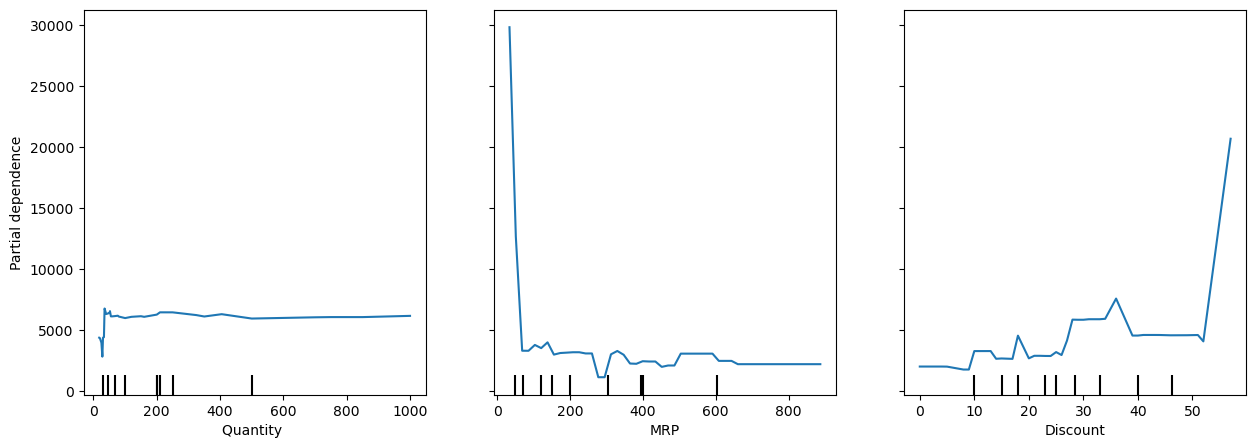

In [22]:
fig , ax = plt.subplots(figsize=(15, 5))
display = PartialDependenceDisplay.from_estimator(
    estimator= model,
    X=x,
    features=features,
    grid_resolution= 50,
    ax= ax 
)